# Inadimplência no Pix Parcelado — 1. Análise Exploratória

Esse notebook é um estudo que fiz pra praticar análise de dados aplicada a crédito,
usando como tema o **Pix parcelado** (um produto que virou bem comum nos bancos
digitais). Simulei uma base de compras parceladas e fui atrás de responder algumas
perguntas que fariam sentido pra um time de crédito/cobrança:

- Quem são os clientes que mais atrasam?
- O número de parcelas influencia na inadimplência?
- Cliente recorrente atrasa menos?

Os dados são **fictícios**, gerados por mim em `data/gerar_dados.py` (não é dado real
de ninguém).

Esse é o notebook 1 de 3:
1. **Análise exploratória** (esse aqui)
2. Estatística + teste A/B
3. Modelo simples de IA pra prever inadimplência


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/pix_parcelado.csv")
df.head()


,cliente_id,idade,renda_estimada,valor_compra,qtd_parcelas,ja_usou_pix_parcelado_antes,score_credito,inadimplente,estrategia_lembrete,recuperou
0,CLI1000,22,2369.71,1814.17,4,1,834,0,NaN,0
1,CLI1001,43,1154.48,2600.64,4,0,802,0,NaN,0
2,CLI1002,21,2428.98,2223.55,9,0,629,0,NaN,0
3,CLI1003,37,2568.09,1837.05,9,0,516,1,Lembrete com opção de renegociar,0
4,CLI1004,41,5432.11,1546.46,9,0,506,0,NaN,0


## Dando uma primeira olhada nos dados

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cliente_id                   3000 non-null   str    
 1   idade                        3000 non-null   int64  
 2   renda_estimada               3000 non-null   float64
 3   valor_compra                 3000 non-null   float64
 4   qtd_parcelas                 3000 non-null   int64  
 5   ja_usou_pix_parcelado_antes  3000 non-null   int64  
 6   score_credito                3000 non-null   int64  
 7   inadimplente                 3000 non-null   int64  
 8   estrategia_lembrete          843 non-null    str    
 9   recuperou                    3000 non-null   int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 234.5 KB


In [3]:
df.describe()


,idade,renda_estimada,valor_compra,qtd_parcelas,ja_usou_pix_parcelado_antes,score_credito,inadimplente,recuperou
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,40.546333,2261.684867,1524.396363,4.965667,0.390667,601.580000,0.281000,0.095667
std,13.704201,1157.540793,843.198753,3.164779,0.487981,145.831825,0.449562,0.294183
min,18.000000,900.000000,51.120000,2.000000,0.000000,300.000000,0.000000,0.000000
25%,28.000000,1418.040000,798.357500,3.000000,0.000000,501.000000,0.000000,0.000000
50%,40.000000,2008.970000,1526.700000,4.000000,0.000000,602.000000,0.000000,0.000000
75%,52.000000,2774.042500,2257.985000,6.000000,1.000000,702.000000,1.000000,0.000000
max,64.000000,9628.090000,2997.870000,12.000000,1.000000,1000.000000,1.000000,1.000000


In [4]:
# taxa de inadimplência geral, só pra ter um número de partida
taxa_geral = df["inadimplente"].mean()
print(f"Taxa de inadimplência geral: {taxa_geral:.1%}")


Taxa de inadimplência geral: 28.1%


## A quantidade de parcelas influencia na inadimplência?

Minha hipótese aqui é que quanto mais parcelado, maior a chance da pessoa atrasar
(faz sentido, o compromisso fica mais longo). Vamos ver se os dados confirmam isso.


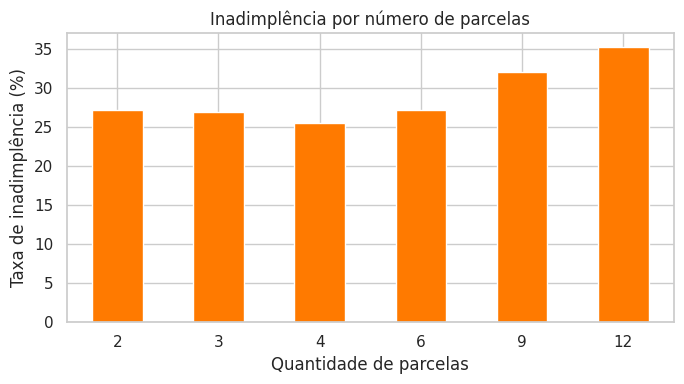

In [5]:
inad_por_parcela = df.groupby("qtd_parcelas")["inadimplente"].mean() * 100

fig, ax = plt.subplots(figsize=(7,4))
inad_por_parcela.plot(kind="bar", color="#FF7A00", ax=ax)
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_xlabel("Quantidade de parcelas")
ax.set_title("Inadimplência por número de parcelas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/inadimplencia_parcelas.png", dpi=120)
plt.show()


Dá pra ver que conforme aumenta o número de parcelas, a inadimplência também
tende a subir. Faz sentido: compras em mais vezes representam um comprometimento
maior no orçamento da pessoa ao longo do tempo.

## Cliente que já usou o Pix parcelado antes atrasa menos?

Outra hipótese: quem já é cliente recorrente do produto tende a ser mais
organizado com os pagamentos (ou já foi "filtrado" naturalmente, já que quem
atrasa muito tende a parar de usar).


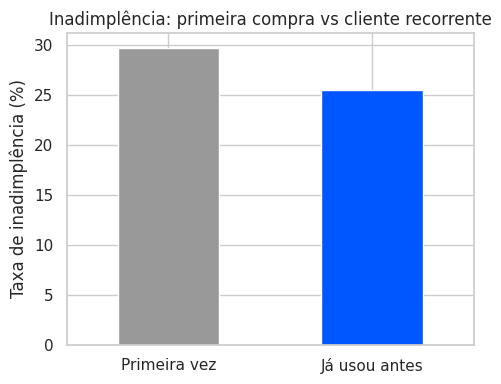

Primeira vez     29.759300
Já usou antes    25.511945
Name: inadimplente, dtype: float64


In [6]:
tabela = df.groupby("ja_usou_pix_parcelado_antes")["inadimplente"].mean() * 100
tabela.index = ["Primeira vez", "Já usou antes"]

fig, ax = plt.subplots(figsize=(5,4))
tabela.plot(kind="bar", color=["#999999", "#0057FF"], ax=ax)
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência: primeira compra vs cliente recorrente")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/inadimplencia_recorrencia.png", dpi=120)
plt.show()

print(tabela)


## E o valor da compra em relação à renda?

Faz sentido pensar que quanto maior o "peso" da compra no orçamento da pessoa,
maior a chance dela não conseguir pagar. Criei uma coluna simples de
comprometimento de renda pra checar isso.


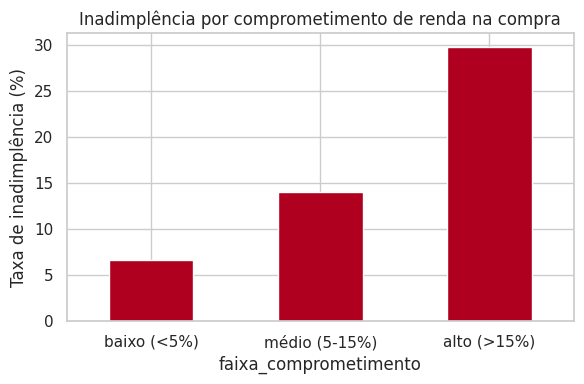

In [7]:
df["comprometimento_renda"] = df["valor_compra"] / df["renda_estimada"]

df["faixa_comprometimento"] = pd.cut(
    df["comprometimento_renda"],
    bins=[0, 0.05, 0.15, 10],
    labels=["baixo (<5%)", "médio (5-15%)", "alto (>15%)"]
)

tabela_comprometimento = df.groupby("faixa_comprometimento")["inadimplente"].mean() * 100

fig, ax = plt.subplots(figsize=(6,4))
tabela_comprometimento.plot(kind="bar", color="#B00020", ax=ax)
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência por comprometimento de renda na compra")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/inadimplencia_comprometimento.png", dpi=120)
plt.show()


## O que deu pra ver nessa primeira análise

- Quanto mais parcelas, maior a inadimplência
- Cliente recorrente parece atrasar menos que cliente de primeira compra
- Quanto maior o peso da compra na renda da pessoa, maior o risco de atraso

No próximo notebook eu confirmo se essas diferenças são estatisticamente
significativas ou se podem ser só coincidência da amostra, e testo duas
estratégias diferentes de cobrança (teste A/B).
